### Import and data load

In [11]:
# 1 — Set-up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="colorblind")

# for modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# load data
df = pd.read_csv("./dataset.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Task 1 · Exploratory Data Analysis  



In [12]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Target distribution – Churn')

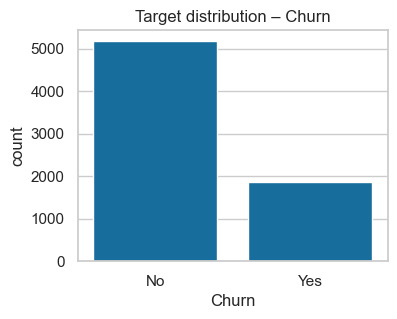

In [ ]:
#target dist.
plt.figure(figsize=(4,3))
sns.countplot(x="Churn", data=df)
plt.title("Target distribution – Churn")

/var/folders/k7/zrb79cq9245_0f4xyq46n7680000gn/T/ipykernel_23069/3534714814.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


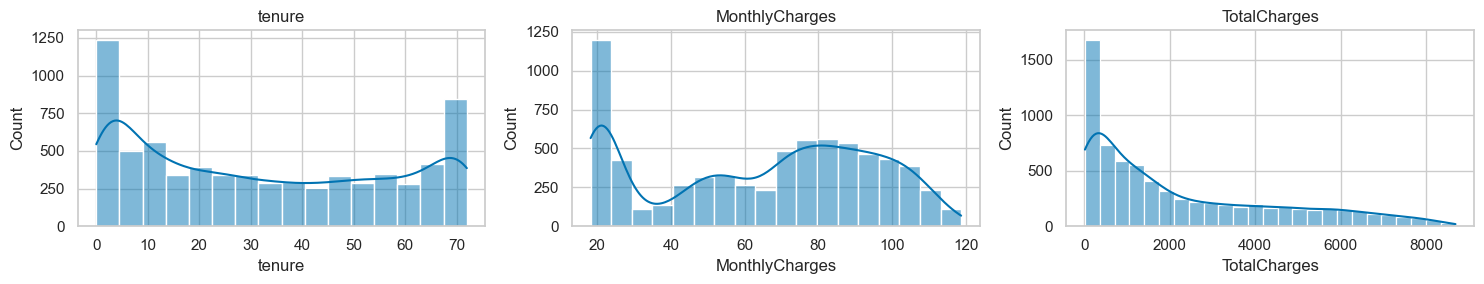

In [ ]:
#key numerical histograms
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# histograms 
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for i, c in enumerate(num_cols):
    sns.histplot(data=df, x=c, ax=axes[i], kde=True)
    axes[i].set_title(c)

plt.tight_layout()



/var/folders/k7/zrb79cq9245_0f4xyq46n7680000gn/T/ipykernel_23069/512409208.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sns.barplot(x=c, y="Churn", data=df.replace({"Yes":1,"No":0}),
/var/folders/k7/zrb79cq9245_0f4xyq46n7680000gn/T/ipykernel_23069/512409208.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=15)
/var/folders/k7/zrb79cq9245_0f4xyq46n7680000gn/T/ipykernel_23069/512409208.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.

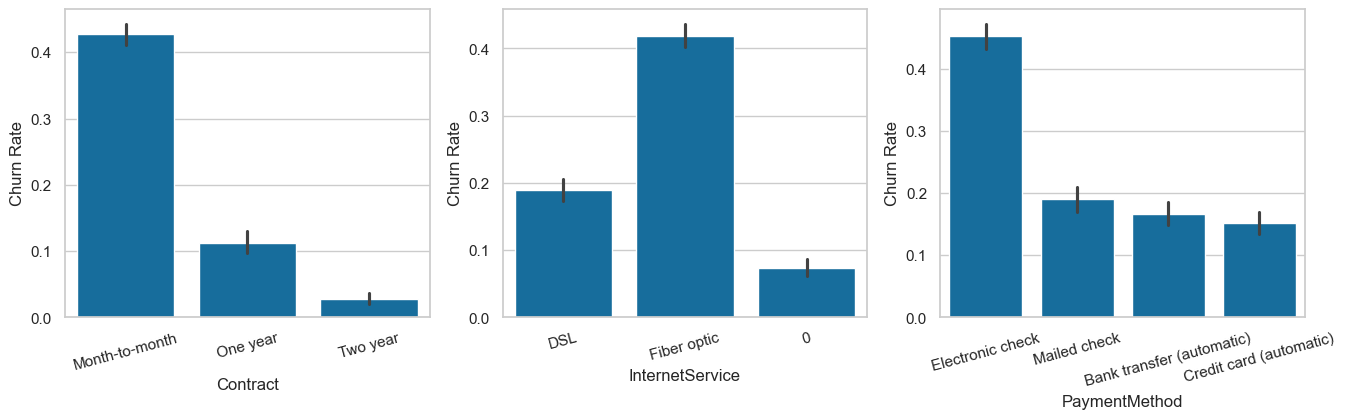

In [16]:
# Churn vs Key Features (Barplots)
cat_cols = ["Contract","InternetService","PaymentMethod"]
fig, ax = plt.subplots(1,3, figsize=(16,4))
for i,c in enumerate(cat_cols):
    sns.barplot(x=c, y="Churn", data=df.replace({"Yes":1,"No":0}),
                estimator=np.mean, ax=ax[i])
    ax[i].set_ylabel("Churn Rate")
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=15)


## feature selection and pre-processing
### Selected features for modelling  
We keep **tenure, MonthlyCharges, Contract, InternetService**.

* **Contract** (month-to-month / one year / two year) shows the strongest
  Churn rate separation (~43 % vs 11 %).  
* **InternetService** (DSL / Fiber / None) is likewise influential.  
* Continuous variables **tenure** & **MonthlyCharges** exhibit clear
  monotonic trends with Churn probability (see plots above).

### Cleaning steps  
* Convert `TotalCharges` to numeric; impute 11 blank rows with median.  
* Drop customer ID (irrelevant).  
* Encode categorical predictors using **one-hot**.  
* Standard-scale numeric predictors so Logistic-Regression converges faster.

In [17]:
# cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df.drop(columns=["customerID"], inplace=True)

X = df[["tenure","MonthlyCharges","Contract","InternetService"]]
y = df["Churn"].map({"Yes":1,"No":0})

num_feats = ["tenure","MonthlyCharges"]
cat_feats = ["Contract","InternetService"]

pre = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_feats),
            ("cat", OneHotEncoder(drop="first"), cat_feats)
        ])

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y)


/var/folders/k7/zrb79cq9245_0f4xyq46n7680000gn/T/ipykernel_23069/2213065822.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
